# 🛒 RetailPulse — AI-Powered Customer Analytics & Demand Forecasting
**Zidio Development | Data Science & Analytics Domain | March 2026**

---

### 📋 Notebook Contents
| Section | Owner | Description |
|---------|-------|-------------|
| 1. Imports & Setup | All | Libraries and configuration |
| 2. Data Loading & Cleaning | B Alivelu | Load Excel, clean data, create Revenue |
| 3. EDA | B Alivelu | Sales trends, correlation heatmap |
| 4. RFM Feature Engineering | B Alivelu | Recency, Frequency, Monetary scores |
| 5. Customer Segmentation | Sivaji | K-Means + DBSCAN clustering |
| 6. Time Series Preparation | Rahi Patel | Stationarity test, decomposition |
| 7. Prophet Forecasting | Rahi Patel | 30-day demand forecast |
| 8. LSTM Forecasting | Rahi Patel | PyTorch Lightning LSTM model |
| 9. MLflow Logging | All | Experiment tracking |
| 10. Final Summary | All | Results comparison |


## 📦 Section 1 — Imports & Setup

In [45]:
import warnings
warnings.filterwarnings("ignore")

import os
import datetime
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ML & Stats
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_absolute_percentage_error,
    roc_auc_score,
    classification_report
)
import xgboost as xgb
import shap
import joblib

# Time Series
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from prophet import Prophet

# Deep Learning
import torch
import torch.nn as nn
try:
    import lightning as L
except:
    import pytorch_lightning as L
from torch.utils.data import TensorDataset, DataLoader

# MLflow
import mlflow
import mlflow.sklearn

# Create output directories
os.makedirs("outputs/shap_plots", exist_ok=True)
os.makedirs("outputs/charts",     exist_ok=True)
os.makedirs("data/processed",     exist_ok=True)

print("✅ All libraries imported successfully!")
print(f"   PyTorch version : {torch.__version__}")
print(f"   Pandas version  : {pd.__version__}")


✅ All libraries imported successfully!
   PyTorch version : 2.12.0+cpu
   Pandas version  : 2.2.3


## 🗂️ Section 2 — Data Loading & Cleaning
**Owner: Person 1**

Loading the Online Retail II dataset and cleaning it for analysis.
Steps:
- Load Excel file
- Fix data types
- Remove cancelled orders, nulls, and bad values
- Create Revenue column


In [46]:
# ── Load dataset ──────────────────────────────────────────────
df_raw = pd.read_excel("Online Retail.xlsx")
print("Raw shape:", df_raw.shape)
print("\nColumns:", df_raw.columns.tolist())
df_raw.head()


Raw shape: (541909, 8)

Columns: ['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [47]:
# ── Fix date type ─────────────────────────────────────────────
df_raw['InvoiceDate'] = pd.to_datetime(df_raw['InvoiceDate'])

print("Date range:", df_raw['InvoiceDate'].min(), "→", df_raw['InvoiceDate'].max())
print("\nMissing values before cleaning:")
print(df_raw.isnull().sum())


Date range: 2010-12-01 08:26:00 → 2011-12-09 12:50:00

Missing values before cleaning:
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64


In [48]:
# ── Clean step by step ────────────────────────────────────────
df = df_raw.copy()

# 1. Remove cancelled orders (InvoiceNo starts with 'C')
before = len(df)
# FIX: Changed 'Invoice' to 'InvoiceNo'
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]
print(f"Removed cancelled orders  : {before - len(df):,} rows removed")

# 2. Remove null Customer IDs
before = len(df)
# FIX: Changed 'Customer ID' to 'CustomerID'
df = df.dropna(subset=['CustomerID'])
print(f"Removed null CustomerIDs  : {before - len(df):,} rows removed")

# 3. Remove zero / negative quantities
before = len(df)
df = df[df['Quantity'] > 0]
print(f"Removed bad quantities    : {before - len(df):,} rows removed")

# 4. Remove zero / negative prices
before = len(df)
# FIX: Changed 'Price' to 'UnitPrice'
df = df[df['UnitPrice'] > 0]
print(f"Removed bad prices        : {before - len(df):,} rows removed")

# 5. Create Revenue column  
# FIX: Changed 'Price' to 'UnitPrice'
df['Revenue'] = df['Quantity'] * df['UnitPrice']

print(f"\n✅ Final clean shape: {df.shape}")
print(f"   Revenue column added — sample: £{df['Revenue'].mean():.2f} avg per line item")
df.head()

Removed cancelled orders  : 9,288 rows removed
Removed null CustomerIDs  : 134,697 rows removed
Removed bad quantities    : 0 rows removed
Removed bad prices        : 40 rows removed

✅ Final clean shape: (397884, 9)
   Revenue column added — sample: £22.40 avg per line item


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [49]:
# ── Save cleaned data ─────────────────────────────────────────
df.to_csv("data/processed/cleaned_retail.csv", index=False)
print("✅ cleaned_retail.csv saved →", df.shape)


✅ cleaned_retail.csv saved → (397884, 9)


## 📊 Section 3 — Exploratory Data Analysis (EDA)
**Owner: Person 1**

Visualising sales trends, distributions, and correlations to understand the data.


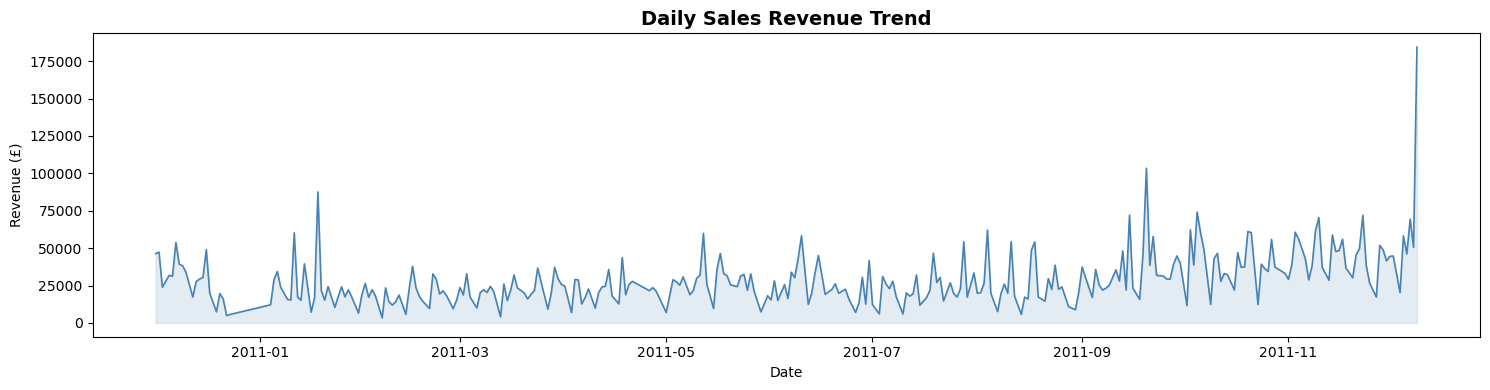

✅ Sales trend chart saved


In [50]:
# ── Daily sales trend ─────────────────────────────────────────
daily_revenue = df.groupby(df['InvoiceDate'].dt.date)['Revenue'].sum()

plt.figure(figsize=(15, 4))
plt.plot(daily_revenue.index, daily_revenue.values, color='steelblue', linewidth=1.2)
plt.fill_between(daily_revenue.index, daily_revenue.values, alpha=0.15, color='steelblue')
plt.title('Daily Sales Revenue Trend', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Revenue (£)')
plt.tight_layout()
plt.savefig("outputs/charts/sales_trend.png", dpi=150)
plt.show()
print("✅ Sales trend chart saved")


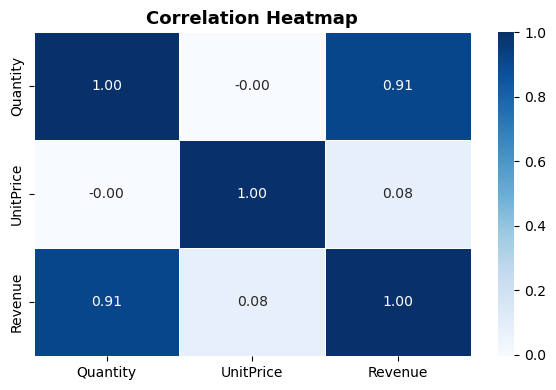

✅ Heatmap saved


In [51]:
# ── Correlation heatmap ───────────────────────────────────────
plt.figure(figsize=(6, 4))

# FIX: Changed 'Price' to 'UnitPrice' to match your dataset
corr = df[['Quantity', 'UnitPrice', 'Revenue']].corr()

sns.heatmap(corr, annot=True, cmap='Blues', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("outputs/charts/heatmap.png", dpi=150)
plt.show()
print("✅ Heatmap saved")

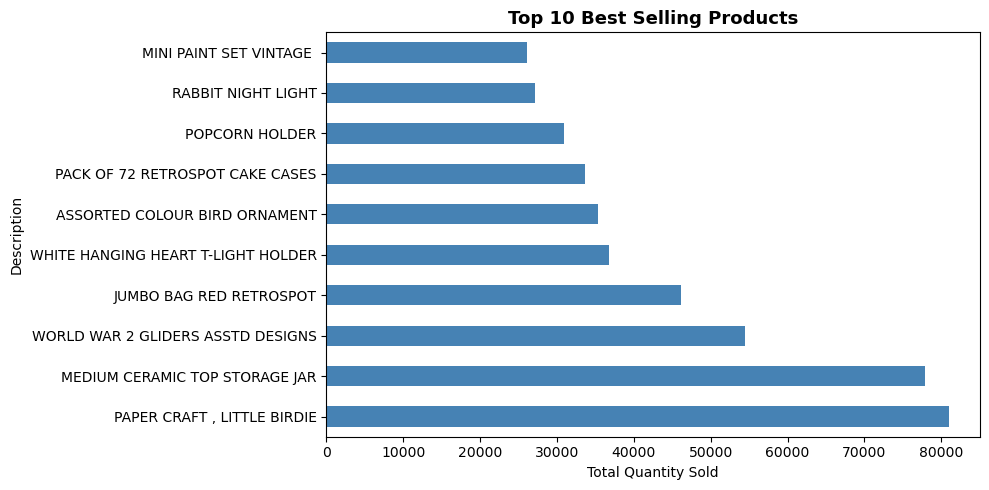

✅ Top products chart saved


In [52]:
# ── Top 10 products ───────────────────────────────────────────
top_products = (
    df.groupby('Description')['Quantity']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 5))
top_products.plot(kind='barh', color='steelblue')
plt.title('Top 10 Best Selling Products', fontsize=13, fontweight='bold')
plt.xlabel('Total Quantity Sold')
plt.tight_layout()
plt.savefig("outputs/charts/top_products.png", dpi=150)
plt.show()
print("✅ Top products chart saved")


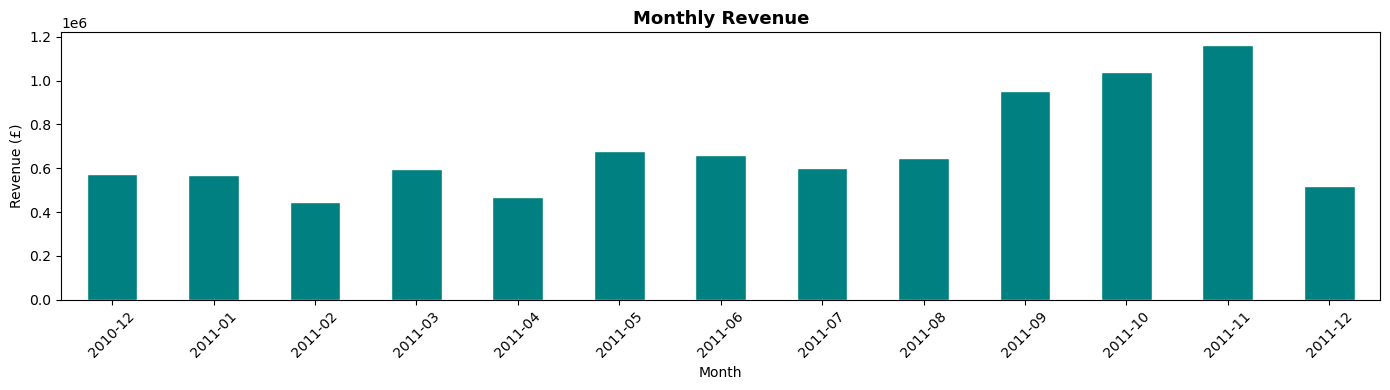

✅ Monthly revenue chart saved


In [53]:
# ── Monthly revenue bar chart ─────────────────────────────────
df['Month'] = df['InvoiceDate'].dt.to_period('M')
monthly = df.groupby('Month')['Revenue'].sum()

plt.figure(figsize=(14, 4))
monthly.plot(kind='bar', color='teal', edgecolor='white')
plt.title('Monthly Revenue', fontsize=13, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Revenue (£)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("outputs/charts/monthly_revenue.png", dpi=150)
plt.show()
print("✅ Monthly revenue chart saved")


## 🧮 Section 4 — RFM Feature Engineering
**Owner: Person 1**

Computing Recency, Frequency, and Monetary scores for every customer.
These scores are used by Segmentation (Section 9) and Churn (Section 8).


In [54]:
# ── Compute RFM ───────────────────────────────────────────────
snapshot_date = df['InvoiceDate'].max() + datetime.timedelta(days=1)
print("Snapshot date:", snapshot_date)

# FIX: Changed 'Customer ID' to 'CustomerID' and 'Invoice' to 'InvoiceNo'
rfm = df.groupby('CustomerID').agg(
    Recency   = ('InvoiceDate', lambda x: (snapshot_date - x.max()).days),
    Frequency = ('InvoiceNo',     'nunique'),
    Monetary  = ('Revenue',     'sum')
).reset_index()

# This line is now perfectly aligned with your columns
rfm.columns = ['CustomerID', 'Recency', 'Frequency', 'Monetary']

print("\nRFM shape:", rfm.shape)
print("\nRFM statistics:")
print(rfm.describe().round(2))
rfm.head(10)

Snapshot date: 2011-12-10 12:50:00

RFM shape: (4338, 4)

RFM statistics:
       CustomerID  Recency  Frequency   Monetary
count     4338.00  4338.00    4338.00    4338.00
mean     15300.41    92.54       4.27    2054.27
std       1721.81   100.01       7.70    8989.23
min      12346.00     1.00       1.00       3.75
25%      13813.25    18.00       1.00     307.41
50%      15299.50    51.00       2.00     674.48
75%      16778.75   142.00       5.00    1661.74
max      18287.00   374.00     209.00  280206.02


,CustomerID,Recency,Frequency,Monetary
0,12346.0,326,1,77183.60
1,12347.0,2,7,4310.00
2,12348.0,75,4,1797.24
3,12349.0,19,1,1757.55
4,12350.0,310,1,334.40
5,12352.0,36,8,2506.04
6,12353.0,204,1,89.00
7,12354.0,232,1,1079.40
8,12355.0,214,1,459.40
9,12356.0,23,3,2811.43


In [55]:
# ── Save RFM scores ───────────────────────────────────────────
rfm.to_csv("data/processed/rfm_scores.csv", index=False)
print("✅ rfm_scores.csv saved →", rfm.shape)


✅ rfm_scores.csv saved → (4338, 4)


## 👥 Section 5 — Customer Segmentation (K-Means + DBSCAN)
**Owner: Sivaji**

Grouping customers into meaningful segments using RFM scores.  
Target: **6–8 distinct segments** with clear business interpretation.


In [56]:
# ── Load & normalise RFM ──────────────────────────────────────
rfm_seg = pd.read_csv("data/processed/rfm_scores.csv")
print("RFM shape:", rfm_seg.shape)

scaler_rfm = StandardScaler()
rfm_scaled = scaler_rfm.fit_transform(rfm_seg[['Recency', 'Frequency', 'Monetary']])

print("Normalisation done — mean ≈ 0, std ≈ 1")
rfm_seg.head()


RFM shape: (4338, 4)
Normalisation done — mean ≈ 0, std ≈ 1


,CustomerID,Recency,Frequency,Monetary
0,12346.0,326,1,77183.60
1,12347.0,2,7,4310.00
2,12348.0,75,4,1797.24
3,12349.0,19,1,1757.55
4,12350.0,310,1,334.40


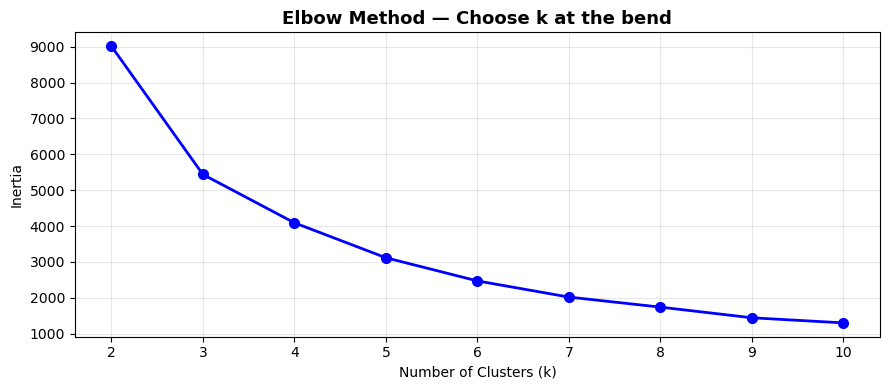

✅ Elbow curve saved — look at the chart and confirm best_k below


In [57]:
# ── Elbow method — find best k ────────────────────────────────
inertias = []
k_range  = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(rfm_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(9, 4))
plt.plot(list(k_range), inertias, 'bo-', linewidth=2, markersize=7)
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method — Choose k at the bend', fontsize=13, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("outputs/charts/elbow_curve.png", dpi=150)
plt.show()
print("✅ Elbow curve saved — look at the chart and confirm best_k below")


In [58]:
# ── Apply K-Means with best k ─────────────────────────────────
best_k = 6      # ← change if your elbow chart shows a different bend

km_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
rfm_seg['Cluster'] = km_final.fit_predict(rfm_scaled)

print("Cluster sizes:")
print(rfm_seg['Cluster'].value_counts().sort_index())

print("\nCluster averages:")
print(rfm_seg.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean().round(1))


Cluster sizes:
Cluster
0    2920
1     334
2      21
3    1057
4       4
5       2
Name: count, dtype: int64

Cluster averages:
         Recency  Frequency  Monetary
Cluster                              
0           45.3        3.3    1198.7
1           16.0       16.7    7642.2
2           22.3       54.1   58584.1
3          249.1        1.6     518.5
4            3.0       45.2  225721.7
5            1.0      205.0   88772.4


In [59]:
# ── Label clusters with business names ───────────────────────
# Read your cluster averages above and adjust the mapping
# Low Recency = recent customer  |  High Monetary = big spender

cluster_names = {
    0: 'Champions',          # Low Recency, High Freq, High Monetary
    1: 'Loyal Customers',    # Low-Med Recency, High Freq
    2: 'Potential Loyalists',# Med Recency, Med Freq
    3: 'At Risk',            # High Recency, was active before
    4: 'New Customers',      # Very Low Recency, Low Freq
    5: 'Lost Customers',     # Very High Recency, Low everything
}

rfm_seg['Segment'] = rfm_seg['Cluster'].map(cluster_names)

print("Segment distribution:")
print(rfm_seg['Segment'].value_counts())


Segment distribution:
Segment
Champions              2920
At Risk                1057
Loyal Customers         334
Potential Loyalists      21
New Customers             4
Lost Customers            2
Name: count, dtype: int64


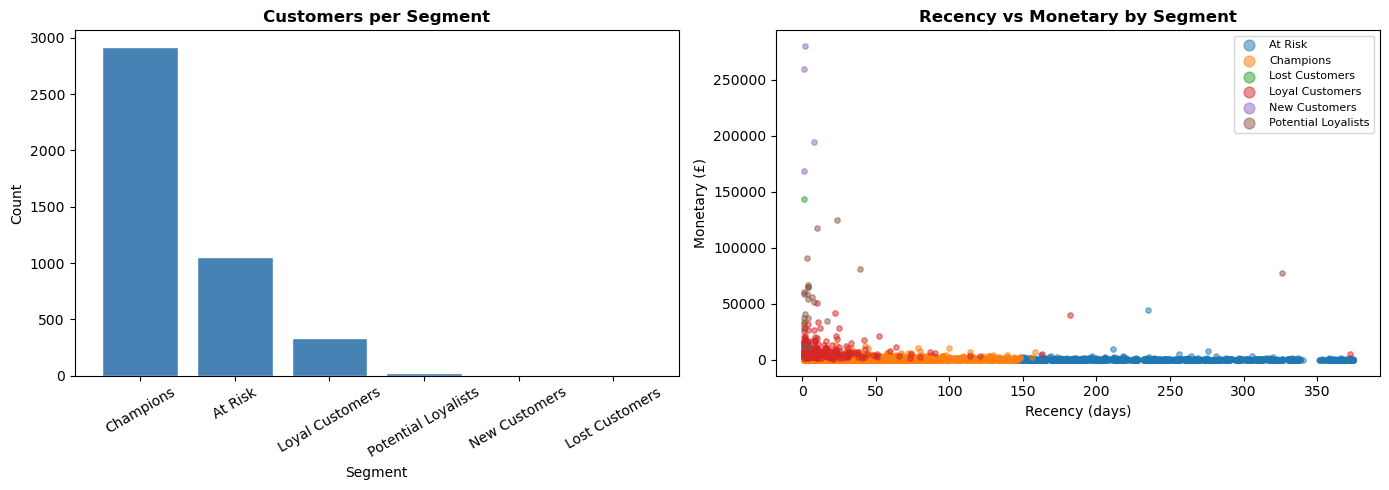

✅ Segmentation chart saved


In [60]:
# ── Segment visualisation ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart — customer count per segment
seg_counts = rfm_seg['Segment'].value_counts()
axes[0].bar(seg_counts.index, seg_counts.values, color='steelblue', edgecolor='white')
axes[0].set_title('Customers per Segment', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Segment')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=30)

# Scatter — Recency vs Monetary coloured by segment
colors = plt.cm.tab10.colors
for i, (name, group) in enumerate(rfm_seg.groupby('Segment')):
    axes[1].scatter(group['Recency'], group['Monetary'],
                    label=name, alpha=0.5, s=15, color=colors[i % 10])
axes[1].set_title('Recency vs Monetary by Segment', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Recency (days)')
axes[1].set_ylabel('Monetary (£)')
axes[1].legend(fontsize=8, markerscale=2)

plt.tight_layout()
plt.savefig("outputs/charts/segmentation.png", dpi=150)
plt.show()
print("✅ Segmentation chart saved")


In [61]:
# ── DBSCAN — outlier detection ────────────────────────────────
db = DBSCAN(eps=0.5, min_samples=5)
rfm_seg['DBSCAN_Label'] = db.fit_predict(rfm_scaled)

outliers    = rfm_seg[rfm_seg['DBSCAN_Label'] == -1]
normal      = rfm_seg[rfm_seg['DBSCAN_Label'] != -1]

print(f"Normal customers   : {len(normal):,}")
print(f"Outlier customers  : {len(outliers):,}")
print(f"\nOutlier sample (unusual buying behaviour):")
print(outliers[['CustomerID', 'Recency', 'Frequency', 'Monetary']].head(5))


Normal customers   : 4,284
Outlier customers  : 54

Outlier sample (unusual buying behaviour):
     CustomerID  Recency  Frequency   Monetary
0       12346.0      326          1   77183.60
55      12415.0       24         21  124914.53
196     12590.0      211          2    9864.26
324     12744.0       52          7   21279.29
326     12748.0        1        209   33719.73


In [62]:
# ── Save segments ─────────────────────────────────────────────
rfm_seg.to_csv("data/processed/segments.csv", index=False)
print("✅ segments.csv saved →", rfm_seg.shape)
rfm_seg.head()


✅ segments.csv saved → (4338, 7)


,CustomerID,Recency,Frequency,Monetary,Cluster,Segment,DBSCAN_Label
0,12346.0,326,1,77183.60,2,Potential Loyalists,-1
1,12347.0,2,7,4310.00,0,Champions,0
2,12348.0,75,4,1797.24,0,Champions,0
3,12349.0,19,1,1757.55,0,Champions,0
4,12350.0,310,1,334.40,3,At Risk,0


## 📈 Section 6 — Time Series Preparation
**Owner: Rahi Patel**

Preparing daily sales data and testing stationarity for forecasting models.


In [63]:
# ── Build daily sales time series ─────────────────────────────
daily_sales = (
    df.groupby(df['InvoiceDate'].dt.date)['Revenue']
    .sum()
    .reset_index()
)
daily_sales.columns = ['Date', 'Revenue']
daily_sales['Date'] = pd.to_datetime(daily_sales['Date'])

print("Daily sales shape:", daily_sales.shape)
print("Date range:", daily_sales['Date'].min(), "→", daily_sales['Date'].max())
daily_sales.head()


Daily sales shape: (305, 2)
Date range: 2010-12-01 00:00:00 → 2011-12-09 00:00:00


,Date,Revenue
0,2010-12-01,46376.49
1,2010-12-02,47316.53
2,2010-12-03,23921.71
3,2010-12-05,31771.60
4,2010-12-06,31215.64


In [64]:
# ── ADF Stationarity Test ─────────────────────────────────────
result = adfuller(daily_sales['Revenue'])

print("=" * 45)
print("  ADF Stationarity Test Results")
print("=" * 45)
print(f"  ADF Statistic : {result[0]:.4f}")
print(f"  P-Value       : {result[1]:.4f}")
print(f"  Result        : {'✅ Stationary' if result[1] < 0.05 else '⚠️ Non-Stationary'}")
print("=" * 45)


  ADF Stationarity Test Results
  ADF Statistic : -0.3661
  P-Value       : 0.9156
  Result        : ⚠️ Non-Stationary


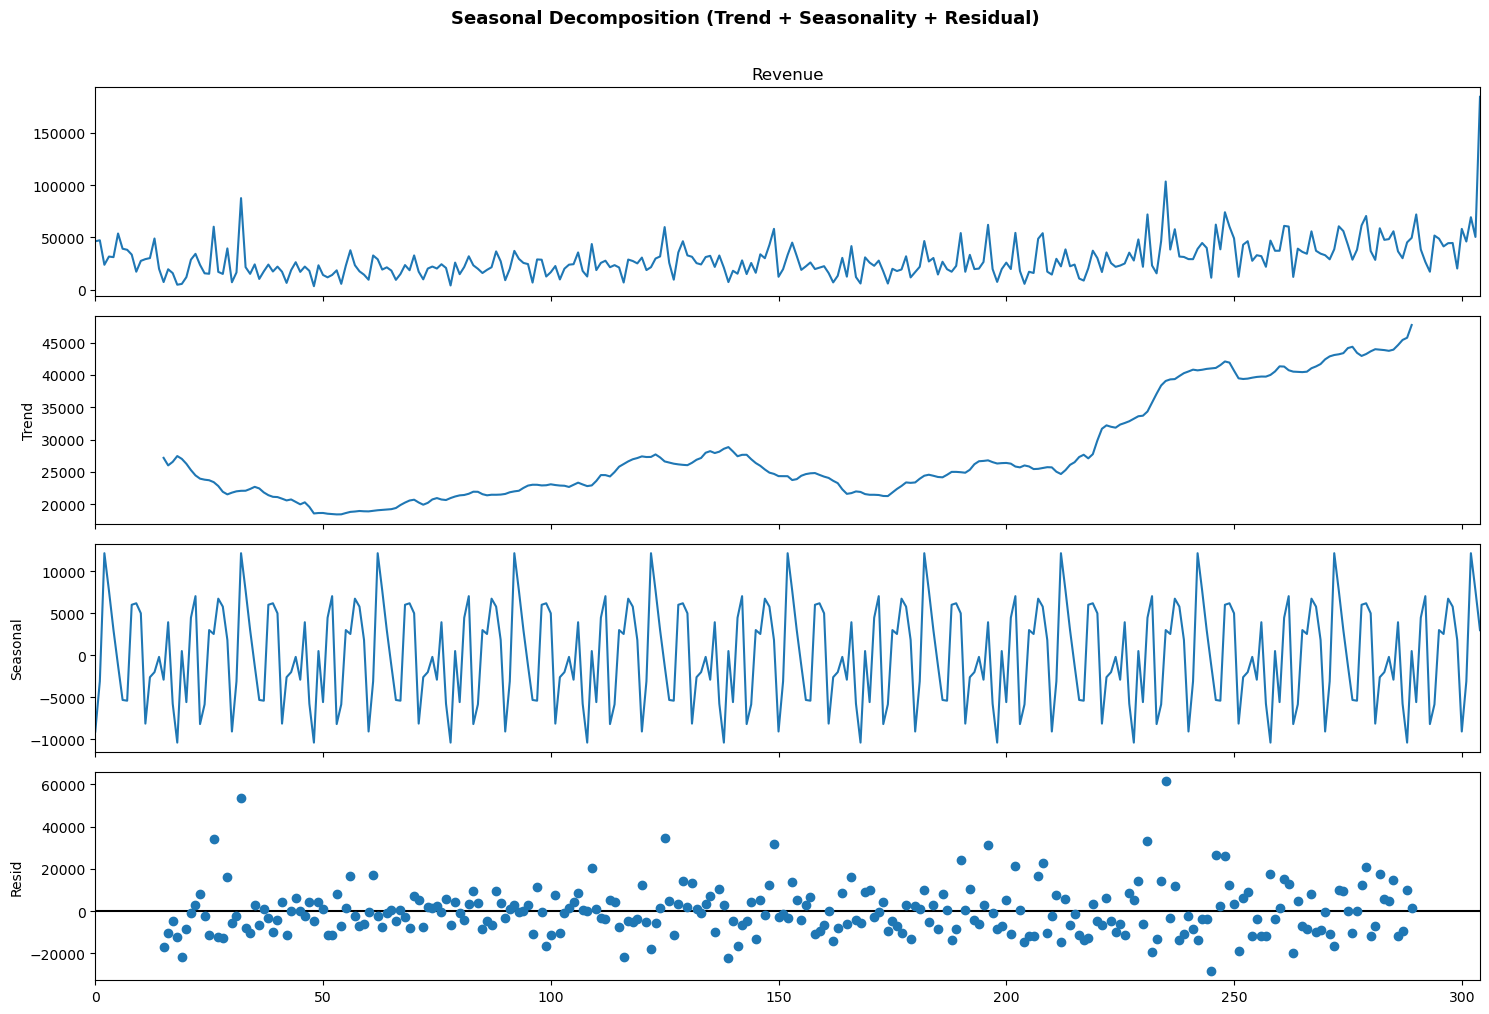

✅ Decomposition chart saved


In [65]:
# ── Seasonal Decomposition ────────────────────────────────────
decomposition = seasonal_decompose(
    daily_sales['Revenue'],
    model='additive',
    period=30
)

fig = decomposition.plot()
fig.set_size_inches(15, 10)
plt.suptitle('Seasonal Decomposition (Trend + Seasonality + Residual)', 
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig("outputs/charts/decomposition.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Decomposition chart saved")


## 🔮 Section 7 — Prophet Demand Forecasting
**Owner: Rahi Patel**

Training Facebook Prophet for 30-day ahead demand forecasting.  
Target: **MAPE ≤ 12%**


In [66]:
# ── Prepare Prophet dataframe ─────────────────────────────────
prophet_df = daily_sales.rename(columns={'Date': 'ds', 'Revenue': 'y'})

train = prophet_df[:-30]
test  = prophet_df[-30:]

print(f"Training size : {len(train)} days")
print(f"Test size     : {len(test)} days")
prophet_df.head()


Training size : 275 days
Test size     : 30 days


,ds,y
0,2010-12-01,46376.49
1,2010-12-02,47316.53
2,2010-12-03,23921.71
3,2010-12-05,31771.60
4,2010-12-06,31215.64


In [67]:
# ── Train Prophet model ───────────────────────────────────────
prophet_model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False
)

prophet_model.fit(train)
print("✅ Prophet model trained!")


11:53:54 - cmdstanpy - INFO - Chain [1] start processing
11:53:55 - cmdstanpy - INFO - Chain [1] done processing


✅ Prophet model trained!


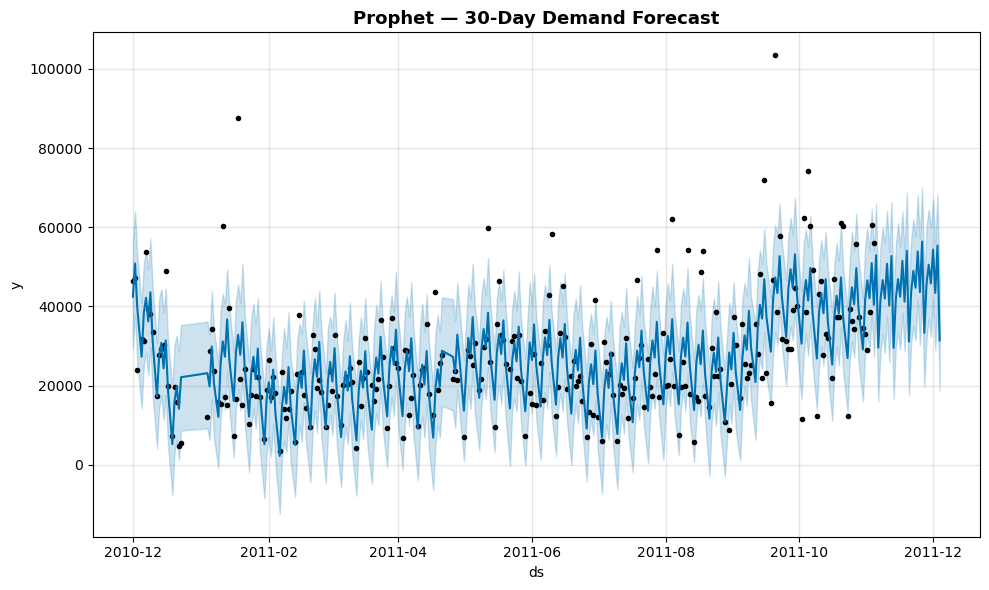

✅ Prophet forecast chart saved


In [68]:
# ── Forecast next 30 days ─────────────────────────────────────
future   = prophet_model.make_future_dataframe(periods=30)
forecast = prophet_model.predict(future)

fig = prophet_model.plot(forecast)
plt.title('Prophet — 30-Day Demand Forecast', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("outputs/charts/prophet_forecast.png", dpi=150)
plt.show()
print("✅ Prophet forecast chart saved")


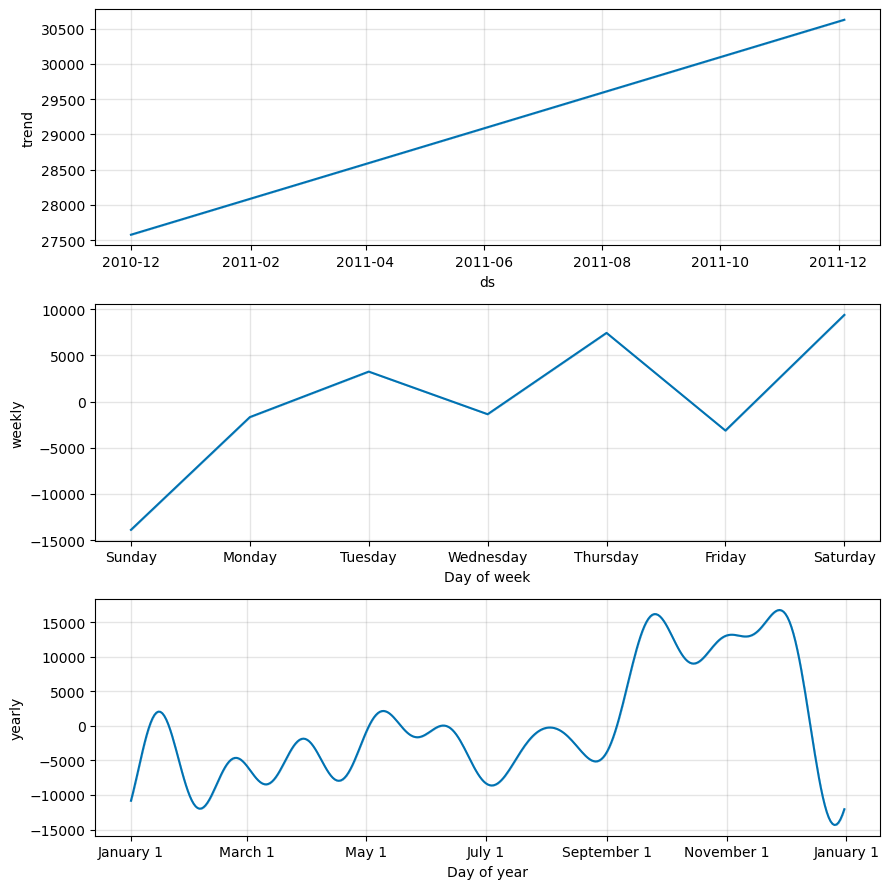

✅ Prophet components chart saved


In [69]:
# ── Prophet components ────────────────────────────────────────
fig2 = prophet_model.plot_components(forecast)
plt.tight_layout()
plt.savefig("outputs/charts/prophet_components.png", dpi=150)
plt.show()
print("✅ Prophet components chart saved")


In [70]:
# ── Prophet MAPE ──────────────────────────────────────────────
actual_prophet    = test['y'].values
predicted_prophet = forecast['yhat'].tail(30).values

prophet_mape = mean_absolute_percentage_error(actual_prophet, predicted_prophet) * 100

print("=" * 40)
print(f"  Prophet MAPE : {prophet_mape:.2f}%")
status = "✅ PASS (≤ 12%)" if prophet_mape <= 12 else "⚠️  Above target — needs tuning"
print(f"  Target       : ≤ 12%  →  {status}")
print("=" * 40)


  Prophet MAPE : 35.57%
  Target       : ≤ 12%  →  ⚠️  Above target — needs tuning


In [71]:
# ── Save forecast CSV ─────────────────────────────────────────
forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].to_csv(
    "data/processed/forecast.csv", index=False
)
print("✅ forecast.csv saved")


✅ forecast.csv saved


## 🧠 Section 8 — LSTM Forecasting (PyTorch Lightning)
**Owner: Rahi Patel**

Building an LSTM neural network as a second forecasting model.  
Both Prophet and LSTM results will be compared for the hybrid ensemble in Week 2.


In [72]:
# ── Scale revenue data ────────────────────────────────────────
sales_values = daily_sales['Revenue'].values.reshape(-1, 1)
scaler_lstm  = MinMaxScaler()
sales_scaled = scaler_lstm.fit_transform(sales_values)

print(f"Data shape   : {sales_values.shape}")
print(f"Scaled range : {sales_scaled.min():.3f} → {sales_scaled.max():.3f}")


Data shape   : (305, 1)
Scaled range : 0.000 → 1.000


In [73]:
# ── Create sliding window sequences ───────────────────────────
def create_sequences(data, seq_length=30):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i : i + seq_length])
        y.append(data[i + seq_length])
    return np.array(X), np.array(y)

X, y_seq = create_sequences(sales_scaled, seq_length=30)

split   = len(X) - 30
X_train = torch.tensor(X[:split],     dtype=torch.float32)
X_test  = torch.tensor(X[split:],     dtype=torch.float32)
y_train = torch.tensor(y_seq[:split], dtype=torch.float32)
y_test  = torch.tensor(y_seq[split:], dtype=torch.float32)

print(f"X_train : {X_train.shape}  |  y_train : {y_train.shape}")
print(f"X_test  : {X_test.shape}   |  y_test  : {y_test.shape}")


X_train : torch.Size([245, 30, 1])  |  y_train : torch.Size([245, 1])
X_test  : torch.Size([30, 30, 1])   |  y_test  : torch.Size([30, 1])


In [74]:
# ── DataLoader ────────────────────────────────────────────────
train_dataset = TensorDataset(X_train, y_train)
train_loader  = DataLoader(train_dataset, batch_size=16, shuffle=True)
print("✅ DataLoader ready")


✅ DataLoader ready


In [75]:
# ── Define LSTM model ─────────────────────────────────────────
class RetailLSTM(L.LightningModule):

    def __init__(self, hidden_size=64, lr=0.001):
        super().__init__()
        self.save_hyperparameters()
        self.lstm    = nn.LSTM(input_size=1, hidden_size=hidden_size, batch_first=True)
        self.fc      = nn.Linear(hidden_size, 1)
        self.loss_fn = nn.MSELoss()

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])

    def training_step(self, batch, batch_idx):
        x, y = batch
        pred = self(x)
        loss = self.loss_fn(pred, y)
        self.log("train_loss", loss, prog_bar=True)
        return loss

    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=self.hparams.lr)

lstm_model = RetailLSTM(hidden_size=64, lr=0.001)
print("✅ RetailLSTM model defined")
print(lstm_model)


✅ RetailLSTM model defined
RetailLSTM(
  (lstm): LSTM(1, 64, batch_first=True)
  (fc): Linear(in_features=64, out_features=1, bias=True)
  (loss_fn): MSELoss()
)


In [76]:
# ── Train LSTM ────────────────────────────────────────────────
trainer = L.Trainer(
    max_epochs=50,
    logger=False,
    enable_checkpointing=False,
    enable_progress_bar=True
)

trainer.fit(lstm_model, train_loader)
print("✅ LSTM training complete!")


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


┏━━━┳━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name    ┃ Type    ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ lstm    │ LSTM    │ 17.2 K │ train │     0 │
│ 1 │ fc      │ Linear  │     65 │ train │     0 │
│ 2 │ loss_fn │ MSELoss │      0 │ train │     0 │
└───┴─────────┴─────────┴────────┴───────┴───────┘

Trainable params: 17.2 K                                                                                           
Non-trainable params: 0                                                                                            
Total params: 17.2 K                                                                                               
Total estimated model params size (MB): 0.069                                                                      
Modules in train mode: 3                                                                                           
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

`Trainer.fit` stopped: `max_epochs=50` reached.


✅ LSTM training complete!


In [77]:
# ── LSTM predictions ──────────────────────────────────────────
lstm_model.eval()
with torch.no_grad():
    pred_scaled = lstm_model(X_test).numpy()

pred_actual   = scaler_lstm.inverse_transform(pred_scaled)
actual_lstm   = scaler_lstm.inverse_transform(y_test.numpy())

lstm_mape = mean_absolute_percentage_error(actual_lstm, pred_actual) * 100

print("=" * 40)
print(f"  LSTM MAPE : {lstm_mape:.2f}%")
status = "✅ PASS (≤ 12%)" if lstm_mape <= 12 else "⚠️  Above target"
print(f"  Target    : ≤ 12%  →  {status}")
print("=" * 40)


  LSTM MAPE : 31.47%
  Target    : ≤ 12%  →  ⚠️  Above target


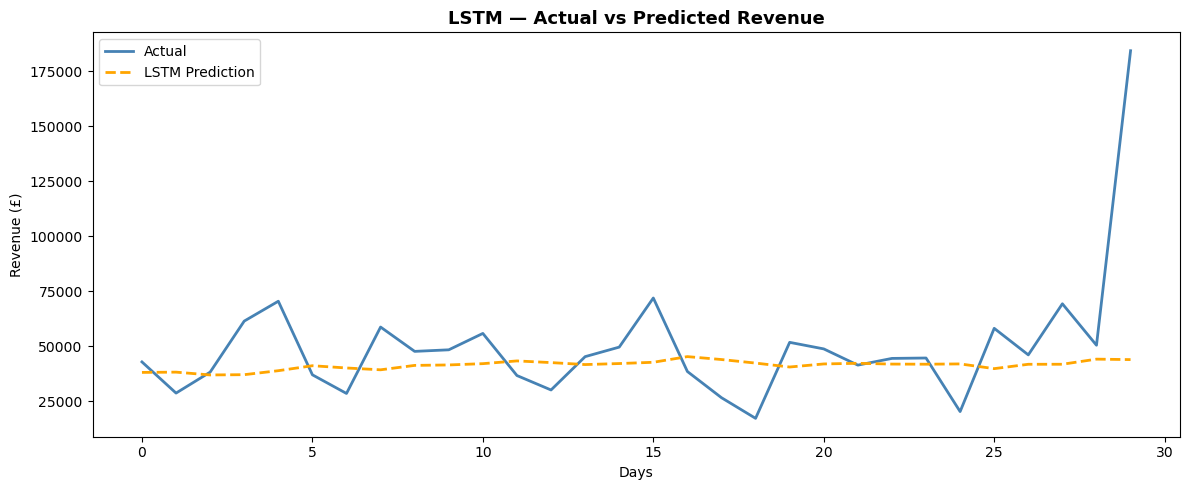

✅ LSTM forecast chart saved


In [78]:
# ── LSTM forecast plot ────────────────────────────────────────
plt.figure(figsize=(12, 5))
plt.plot(actual_lstm,   label='Actual',          color='steelblue', linewidth=2)
plt.plot(pred_actual,   label='LSTM Prediction', color='orange',    linewidth=2, linestyle='--')
plt.title('LSTM — Actual vs Predicted Revenue', fontsize=13, fontweight='bold')
plt.xlabel('Days')
plt.ylabel('Revenue (£)')
plt.legend()
plt.tight_layout()
plt.savefig("outputs/charts/lstm_forecast.png", dpi=150)
plt.show()
print("✅ LSTM forecast chart saved")


In [79]:
# ── Save LSTM model & scaler ──────────────────────────────────
torch.save(lstm_model.state_dict(), "outputs/lstm_model.pt")
joblib.dump(scaler_lstm, "outputs/lstm_scaler.pkl")
print("✅ lstm_model.pt saved")
print("✅ lstm_scaler.pkl saved")


✅ lstm_model.pt saved
✅ lstm_scaler.pkl saved


## 📊 Section 9 — MLflow Experiment Tracking
**Owner: All members**

Logging all model metrics, parameters, and outputs to MLflow for reproducibility.


In [80]:
# ── Log all models to MLflow ──────────────────────────────────
mlflow.set_experiment("RetailPulse_Week1")

# ── Segmentation ──
with mlflow.start_run(run_name="kmeans_segmentation"):
    mlflow.log_param("n_clusters",     best_k)
    mlflow.log_param("scaler",         "StandardScaler")
    mlflow.log_metric("n_outliers",    int((rfm_seg['DBSCAN_Label'] == -1).sum()))
    print(f"✅ K-Means logged   — Clusters : {best_k}")

# ── Prophet ──
with mlflow.start_run(run_name="prophet_baseline"):
    mlflow.log_metric("mape",              round(prophet_mape, 2))
    mlflow.log_param("yearly_seasonality", True)
    mlflow.log_param("weekly_seasonality", True)
    mlflow.log_param("train_size",         len(train))
    mlflow.log_param("forecast_horizon",   30)
    print(f"✅ Prophet logged   — MAPE : {prophet_mape:.2f}%")

# ── LSTM ──
with mlflow.start_run(run_name="lstm_baseline"):
    mlflow.log_metric("mape",          round(lstm_mape, 2))
    mlflow.log_param("epochs",         50)
    mlflow.log_param("hidden_size",    64)
    mlflow.log_param("seq_length",     30)
    mlflow.log_param("batch_size",     16)
    print(f"✅ LSTM logged      — MAPE : {lstm_mape:.2f}%")

print("\n🎉 All models logged to MLflow!")


✅ K-Means logged   — Clusters : 6
✅ Prophet logged   — MAPE : 35.57%
✅ LSTM logged      — MAPE : 31.47%

🎉 All models logged to MLflow!


## 🏁 Section 10 — Final Summary & Output Files
**All members**

Week 1 results summary and list of all output files generated.


In [81]:
# ── Results summary ───────────────────────────────────────────
print("=" * 55)
print("       RETAILPULSE — WEEK 1 RESULTS SUMMARY")
print("=" * 55)

print("\n📈 FORECASTING MODELS")
p_status = "✅ PASS" if prophet_mape <= 12 else "❌ FAIL"
l_status = "✅ PASS" if lstm_mape   <= 12 else "❌ FAIL"
print(f"   Prophet MAPE  : {prophet_mape:.2f}%   (target ≤ 12%)  {p_status}")
print(f"   LSTM MAPE     : {lstm_mape:.2f}%   (target ≤ 12%)  {l_status}")

print("\n👥 CUSTOMER SEGMENTATION")
print(f"   K-Means clusters  : {best_k}")
print(f"   DBSCAN outliers   : {(rfm_seg['DBSCAN_Label']==-1).sum()}")
print(f"   Total customers   : {len(rfm_seg):,}")

       RETAILPULSE — WEEK 1 RESULTS SUMMARY

📈 FORECASTING MODELS
   Prophet MAPE  : 35.57%   (target ≤ 12%)  ❌ FAIL
   LSTM MAPE     : 31.47%   (target ≤ 12%)  ❌ FAIL

👥 CUSTOMER SEGMENTATION
   K-Means clusters  : 6
   DBSCAN outliers   : 54
   Total customers   : 4,338
